# Automatic Differentiation and Gradient Descent

**DesignSafe AI Training**

[![Try on DesignSafe](https://raw.githubusercontent.com/DesignSafe-CI/training-ai/main/DesignSafe-Badge.svg)](https://jupyter.designsafe-ci.org/hub/user-redirect/lab/tree/CommunityData/Training/training-ai/02b-automatic-differentiation.ipynb)

> Ported verbatim from the [SciML course](https://kks32-courses.github.io/sciml/00-mlp/mlp.html)
> (Krishna Kumar). The longer treatments are
> [Automatic Differentiation](https://kks32-courses.github.io/sciml/00-mlp/ad.html)
> and [Gradient Descent](https://kks32-courses.github.io/sciml/00-mlp/sgd.html).

Reverse-mode AD is the one piece of machinery the whole session runs on: it trains
the networks here, it builds the PDE residual in the PINN notebook, and it
differentiates the trunk in the operator notebook. This notebook defines it
properly before we rely on it.

---

In [1]:
# Capture figures as notebook outputs. The course notebooks run in a
# live JupyterLab where this is implicit; the published book renders
# saved outputs, so without it every plot is lost.
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random

SEED = 4321
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Set up plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

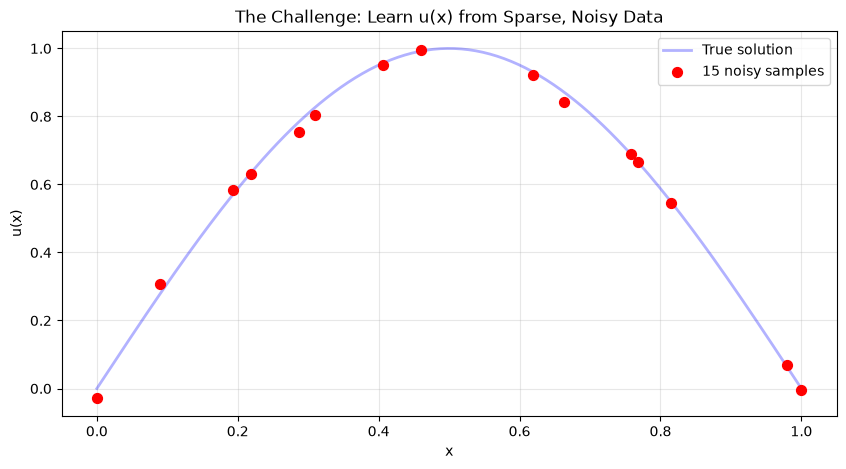

Training with 15 noisy data points


In [3]:
# Generate sparse training data
n_train = 15

# Training points - sparse and noisy
x_train = np.random.rand(n_train)
x_train[0], x_train[-1] = 0, 1  # Include boundaries
x_train = np.sort(x_train)

# Target function: sin(πx)
def target_func(x):
    """Target function: sin(πx)"""
    return np.sin(np.pi * x)

y_train = target_func(x_train) + 0.02 * np.random.randn(n_train)  # Add noise

# Dense grid for visualization
x_test = np.linspace(0, 1, 200)
y_exact = target_func(x_test)

# Visualize the problem
plt.figure(figsize=(10, 5))
plt.plot(x_test, y_exact, 'b-', alpha=0.3, linewidth=2, label='True solution')
plt.scatter(x_train, y_train, s=50, c='red', zorder=5, label=f'{n_train} noisy samples')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.title('The Challenge: Learn u(x) from Sparse, Noisy Data')
plt.show()

print(f"Training with {n_train} noisy data points")

In [4]:
# Tensors for the PyTorch cells below (same 15 samples).
x_train_tensor = torch.FloatTensor(x_train.reshape(-1, 1))
y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
u_train_tensor = y_train_tensor          # alias used by the cells below
x_test_tensor  = torch.FloatTensor(x_test.reshape(-1, 1))
u_test_tensor  = torch.FloatTensor(y_exact.reshape(-1, 1))
print(x_train_tensor.shape, u_train_tensor.shape)

torch.Size([15, 1]) torch.Size([15, 1])


## Gradients, autodiff, and gradient descent

### Training a neural network

Neural networks are trained using an optimization algorithm that iteratively updates the network's weights and biases to minimize a loss function. The loss function measures how far the network's predictions are from the true target outputs in the training data. It is a measure of the model's error.

We quantify this difference using a **Loss Function**, Some common loss functions include:

* Mean squared error (MSE) - The average of the squared differences between the predicted and actual values. Measures the square of the error. Used for regression problems.

* Cross-entropy loss - Measures the divergence between the predicted class probabilities and the true distribution. Used for classification problems. Penalizes confident incorrect predictions.

* Hinge loss - Used for Support Vector Machines classifiers. Penalizes predictions that are on the wrong side of the decision boundary.

For our function approximation (regression) task, the Mean Squared Error (MSE) is a common choice:

$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^N \left(u_{NN}(x_i; \theta) - u_i\right)^2$$

Minimizing this loss function with respect to the parameters $\theta$ is an optimization problem.


Loss optimization is the process of finding the network weights that acheives the lowest loss.

$$ 
\begin{align}
\boldsymbol{w^*} &= \argmin_{\boldsymbol{w}}\frac{1}{n}\sum_{i=1}^n \mathcal{L}(f(x^{(i)};\boldsymbol{w}),y^{(i)})\\
\boldsymbol{w^*} &= \argmin_{\boldsymbol{w}} J(\boldsymbol{w})
\end{align}
$$

The training process works like this:

1. **Initialization**: The weights and biases of the network are initialized, often with small random numbers.

2. **Forward Pass**: The input is passed through the network, layer by layer, applying the necessary transformations (e.g., linear combinations of weights and inputs followed by activation functions) until an output is obtained.

3. **Calculate Loss**: A loss function is used to quantify the difference between the predicted output and the actual target values.

4. **Backward Pass (Backpropagation)**: The gradients of the loss with respect to the parameters (weights and biases) are computed using the chain rule for derivatives. This process is known as backpropagation.

5. **Update Parameters**: The gradients computed in the backward pass are used to update the parameters of the network, typically using optimization algorithms like stochastic gradient descent (SGD) or more sophisticated ones like Adam. The update is done in the direction that minimizes the loss.

6. **Repeat**: Steps 2-5 are repeated using the next batch of data until a stopping criterion is met, such as a set number of epochs (full passes through the training dataset) or convergence to a minimum loss value.

7. **Validation**: The model is evaluated on a separate validation set to assess its generalization to unseen data.

The goal of training is to find the optimal set of weights and biases $\theta^*$ for the network that minimize the difference between the network's output $u_{NN}(x; \theta)$ and the true training data $u_{train}$.

### Computing gradients with Automatic Differentiation

> The Core Insight: Functions Are Computational Graphs

Every computer program that evaluates a mathematical function can be viewed as a **computational graph**. Consider this simple function:

[![Button](https://img.shields.io/badge/Go%20to-Interactive%20Demo-blue?style=for-the-badge&logo=airplayvideo&logoColor=white)](https://kks32-courses.github.io/sciml/00-mlp/ad.html)

In [5]:
def f(x1, x2):
    y = x1**2 + x2
    return y

This creates a computational graph where each operation is a node. This decomposition is the key insight that makes automatic differentiation possible.

![AD forward pass](figs/ad3.png)

### Forward Mode Automatic Differentiation

Forward mode AD computes derivatives by propagating derivative information **forward** through the computational graph, following the same path as the function evaluation.

![AD forward evaluation](figs/forward-mode-ad.png)

#### Forward Mode: Computing $\frac{\partial y}{\partial x_1}$

Starting with our function $y = x_1^2 + x_2$, let's trace through the computation:

1. **Seed the input**: Set $\dot{x}_1 = 1$ and $\dot{x}_2 = 0$ (we're differentiating w.r.t. $x_1$)

2. **Forward propagation**:
   - $v_1 = x_1^2$, so $\dot{v}_1 = 2x_1 \cdot \dot{x}_1 = 2x_1 \cdot 1 = 2x_1$
   - $y = v_1 + x_2$, so $\dot{y} = \dot{v}_1 + \dot{x}_2 = 2x_1 + 0 = 2x_1$

3. **Result**: $\frac{\partial y}{\partial x_1} = 2x_1$

#### Forward Mode: Computing $\frac{\partial y}{\partial x_2}$

To get the derivative w.r.t. $x_2$, we seed differently:

1. **Seed the input**: Set $\dot{x}_1 = 0$ and $\dot{x}_2 = 1$

2. **Forward propagation**:
   - $v_1 = x_1^2$, so $\dot{v}_1 = 2x_1 \cdot \dot{x}_1 = 2x_1 \cdot 0 = 0$
   - $y = v_1 + x_2$, so $\dot{y} = \dot{v}_1 + \dot{x}_2 = 0 + 1 = 1$

3. **Result**: $\frac{\partial y}{\partial x_2} = 1$

**Key insight**: Forward mode requires one pass per input variable to compute all partial derivatives.

### Reverse Mode Automatic Differentiation

Reverse mode AD (also called **backpropagation**) computes derivatives by propagating derivative information **backward** through the computational graph.

#### The Backward Pass Algorithm

1. **Forward pass**: Compute function values and store intermediate results
2. **Seed the output**: Set $\bar{y} = 1$ (derivative of output w.r.t. itself)
3. **Backward pass**: Use the chain rule to propagate derivatives backward

![Final chain rule AD](figs/ad7.png)

#### Computing All Partial Derivatives in One Pass

The beauty of reverse mode is that it computes **all** partial derivatives in a single backward pass:

1. **Forward pass**: $y = x_1^2 + x_2$ (store intermediate values)

2. **Backward pass with $\bar{y} = 1$**:
   - $\frac{\partial y}{\partial x_1} = \frac{\partial y}{\partial v_1} \cdot \frac{\partial v_1}{\partial x_1} = 1 \cdot 2x_1 = 2x_1$
   - $\frac{\partial y}{\partial x_2} = \frac{\partial y}{\partial x_2} = 1$

**Key insight**: Reverse mode computes gradients w.r.t. all inputs in a single backward pass!

### AD: The Mathematical Foundation

Automatic differentiation works because of a fundamental theorem:

**Chain Rule**: For composite functions $f(g(x))$:
$$\frac{d}{dx}f(g(x)) = f'(g(x)) \cdot g'(x)$$

By systematically applying the chain rule to each operation in a computational graph, AD can compute exact derivatives for arbitrarily complex functions.

### Automatic Differentiation in Practice: PyTorch

Let's see how automatic differentiation works in PyTorch:

In [6]:
import torch

# Define variables that require gradients
x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(3.0, requires_grad=True)

# Define the function
y = x1**2 + x2

# Compute gradients using reverse mode AD
y.backward()

# Access the computed gradients
print(f"dy/dx1: {x1.grad.item()}")  # Should be 2*x1 = 4.0
print(f"dy/dx2: {x2.grad.item()}")  # Should be 1.0

dy/dx1: 4.0
dy/dx2: 1.0


### A More Complex Example: Neural Network

In [7]:
import torch
import torch.nn as nn

# Implement Single-Layer NN in PyTorch

class SingleLayerNN(nn.Module):
    """Single hidden layer neural network for 1D input/output"""
    
    def __init__(self, hidden_size=10):
        super(SingleLayerNN, self).__init__()
        self.hidden = nn.Linear(1, hidden_size)
        self.output = nn.Linear(hidden_size, 1)
        self.activation = nn.Tanh()
    
    def forward(self, x):
        # Forward pass
        x = self.hidden(x)
        x = self.activation(x)
        x = self.output(x)
        return x

# Create network and data
model = SingleLayerNN(hidden_size=10)

# Define MSE loss
criterion = nn.MSELoss() 

# Forward pass: compute predictions
predictions = model(x_train_tensor)
    
# Calculate loss (((output - target)**2).mean())
loss = criterion(predictions, u_train_tensor)
    
# Backward pass: compute gradients
loss.backward()       # Compute gradients of the loss w.r.t. parameters

# Access gradients
for name, param in model.named_parameters():
    print(f"{name}: gradient shape {param.grad.shape}")

hidden.weight: gradient shape torch.Size([10, 1])
hidden.bias: gradient shape torch.Size([10])
output.weight: gradient shape torch.Size([1, 10])
output.bias: gradient shape torch.Size([1])


### When to Use Forward vs Reverse Mode

The choice depends on the structure of your problem:

- **Forward Mode**: Efficient when **few inputs, many outputs** (e.g., $f: \mathbb{R}^n \to \mathbb{R}^m$ with $n \ll m$)
- **Reverse Mode**: Efficient when **many inputs, few outputs** (e.g., $f: \mathbb{R}^n \to \mathbb{R}^m$ with $n \gg m$)

In machine learning, we typically have millions of parameters (inputs) and a single loss function (output), making reverse mode the natural choice.

### Computational Considerations

#### Memory vs Computation Trade-offs

**Forward Mode**:
- Memory: O(1) additional storage
- Computation: O(n) for n input variables

**Reverse Mode**:
- Memory: O(computation graph size)
- Computation: O(1) for any number of input variables

#### Modern Optimizations

1. **Checkpointing**: Trade computation for memory by recomputing intermediate values
2. **JIT compilation**: Compile computational graphs for faster execution
3. **Parallelization**: Distribute gradient computation across multiple devices

### Gradient Descent
Gradient Descent is a first-order iterative optimization algorithm used to find the minimum of a differentiable function. In the context of training a neural network, we are trying to minimize the loss function. 

1. **Initialize Parameters**:

Choose an initial point (i.e., initial values for the weights and biases) in the parameter space, and set a learning rate that determines the step size in each iteration.

2. **Compute the Gradient**:

Calculate the gradient of the loss function with respect to the parameters at the current point. The gradient is a vector that points in the direction of the steepest increase of the function. It is obtained by taking the partial derivatives of the loss function with respect to each parameter.

3. **Update Parameters**:

Move in the opposite direction of the gradient by a distance proportional to the learning rate. This is done by subtracting the gradient times the learning rate from the current parameters:

$$\boldsymbol{w} = \boldsymbol{w} - \eta \nabla J(\boldsymbol{w})$$

Here, $\boldsymbol{w}$ represents the parameters, $\eta$ is the learning rate, and $\nabla J (\boldsymbol{w})$ is the gradient of the loss function $J$ with respect to $\boldsymbol{w}$.

4. **Repeat**:

Repeat steps 2 and 3 until the change in the loss function falls below a predefined threshold, or a maximum number of iterations is reached.

#### Algorithm:

1. Initialize weights randomly $\sim \mathcal{N}(0, \sigma^2)$
2. Loop until convergence
3.   Compute gradient, $\frac{\partial J(\boldsymbol{w})}{\partial \boldsymbol{w}}$
4.   Update weights, $\boldsymbol{w} \leftarrow \boldsymbol{w} - \eta \frac{\partial J(\boldsymbol{w})}{\partial \boldsymbol{w}}$
5. Return weights

![SGD](figs/sgd.gif)

Assuming a loss function is mean squared error (MSE). Let's compute the gradient of the loss with respect to the input weights. 

The loss function is mean squared error:

$$\text{loss} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Where $y_i$ are the true target and $\hat{y}_i$ are the predicted values.

To minimize this loss, we need to compute the gradients with respect to the weights $\mathbf{w}$ and bias $b$:

Using the chain rule, the gradient of the loss with respect to the weights is:
$$\frac{\partial \text{loss}}{\partial \mathbf{w}} = \frac{2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i) \frac{\partial y_i}{\partial \mathbf{w}}$$

The term inside the sum is the gradient of the loss with respect to the output $y_i$, which we called $\text{grad\_output}$:
$$\text{grad\_output} = \frac{2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)$$

The derivative $\frac{\partial y_i}{\partial \mathbf{w}}$ is just the input $\mathbf{x}_i$ multiplied by the derivative of the activation. For simplicity, let's assume linear activation, so this is just $\mathbf{x}_i$:

$$\therefore \frac{\partial \text{loss}}{\partial \mathbf{w}} = \mathbf{X}^T\text{grad\_output}$$

The gradient for the bias is simpler:
$$\frac{\partial \text{loss}}{\partial b} = \sum_{i=1}^{n}\text{grad\_output}_i$$

Finally, we update the weights and bias by gradient descent:

$$\mathbf{w} = \mathbf{w} - \eta \frac{\partial \text{loss}}{\partial \mathbf{w}}$$

$$b = b - \eta \frac{\partial \text{loss}}{\partial b}$$

Where $\eta$ is the learning rate.

#### Variants:

There are several variants of Gradient Descent that modify or enhance these basic steps, including:

- **Stochastic Gradient Descent (SGD)**: Instead of using the entire dataset to compute the gradient, SGD uses a single random data point (or small batch) at each iteration. This adds noise to the gradient but often speeds up convergence and can escape local minima.

- **Momentum**: Momentum methods use a moving average of past gradients to dampen oscillations and accelerate convergence, especially in cases where the loss surface has steep valleys.

- **Adaptive Learning Rate Methods**: Techniques like Adagrad, RMSprop, and Adam adjust the learning rate individually for each parameter, often leading to faster convergence.

#### Limitations:

* It may converge to a local minimum instead of a global minimum if the loss surface is not convex.
* Convergence can be slow if the learning rate is not properly tuned.
* Sensitive to the scaling of features; poorly scaled data can cause the gradient descent to take a long time to converge or even diverge.

#### Effect of learning rate

The learning rate in gradient descent is a critical hyperparameter that can significantly influence the model's training dynamics. Let us now look at how the learning rate affects local minima, overshooting, and convergence:

1. Effect on Local Minima:

- High Learning Rate: A large learning rate can help the model escape shallow local minima, leading to the discovery of deeper (potentially global) minima. However, it can also cause instability, making it hard to settle in a good solution.

- Low Learning Rate: A small learning rate may cause the model to get stuck in local minima, especially in complex loss landscapes with many shallow valleys. The model can lack the "energy" to escape these regions.

2. Effect on Overshooting:

- High Learning Rate: If the learning rate is set too high, the updates may be so large that they overshoot the minimum and cause the algorithm to diverge, or oscillate back and forth across the valley without ever reaching the bottom. This oscillation can be detrimental to convergence.
   
- Low Learning Rate: A very low learning rate will likely avoid overshooting but may lead to extremely slow convergence, as the updates to the parameters will be minimal. It might result in getting stuck in plateau regions where the gradient is small.

3. Effect on Convergence:

- High Learning Rate: While it can speed up convergence initially, a too-large learning rate risks instability and divergence, as mentioned above. The model may never converge to a satisfactory solution.
   
- Low Learning Rate: A small learning rate ensures more stable and reliable convergence but can significantly slow down the process. If set too low, it may also lead to premature convergence to a suboptimal solution.

##### Finding the Right Balance:

Choosing the right learning rate is often a trial-and-error process, sometimes guided by techniques like learning rate schedules or adaptive learning rate algorithms like Adam. These approaches attempt to balance the trade-offs by adjusting the learning rate throughout training, often starting with larger values to escape local minima and avoid plateaus, then reducing it to stabilize convergence.


[![Button](https://img.shields.io/badge/Go%20to-Interactive%20Demo:SGD-blue?style=for-the-badge&logo=airplayvideo&logoColor=white)](https://kks32-courses.github.io/sciml/00-mlp/sgd.html)

In [8]:
# Implement PyTorch Training Loop Function
def train_network(model, x_train, u_train, epochs=5000, lr=0.01):
    """Train a neural network model using MSE loss and Adam optimizer"""
    criterion = nn.MSELoss() # Mean Squared Error Loss
    optimizer = optim.Adam(model.parameters(), lr=lr) # Adam optimizer
    
    losses = []
    
    for epoch in range(epochs):
        # Forward pass: compute predictions
        predictions = model(x_train)
        
        # Calculate loss
        loss = criterion(predictions, u_train)
        
        # Backward pass: compute gradients
        optimizer.zero_grad() # Clear previous gradients
        loss.backward()       # Compute gradients of the loss w.r.t. parameters
        
        # Optimizer step: update parameters
        optimizer.step()      # Perform a single optimization step
        
        losses.append(loss.item())
        
        # Optional: Print loss periodically
        # if (epoch + 1) % 1000 == 0:
        #     print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')
    
    return losses

Final loss for 10 neurons: 0.000101


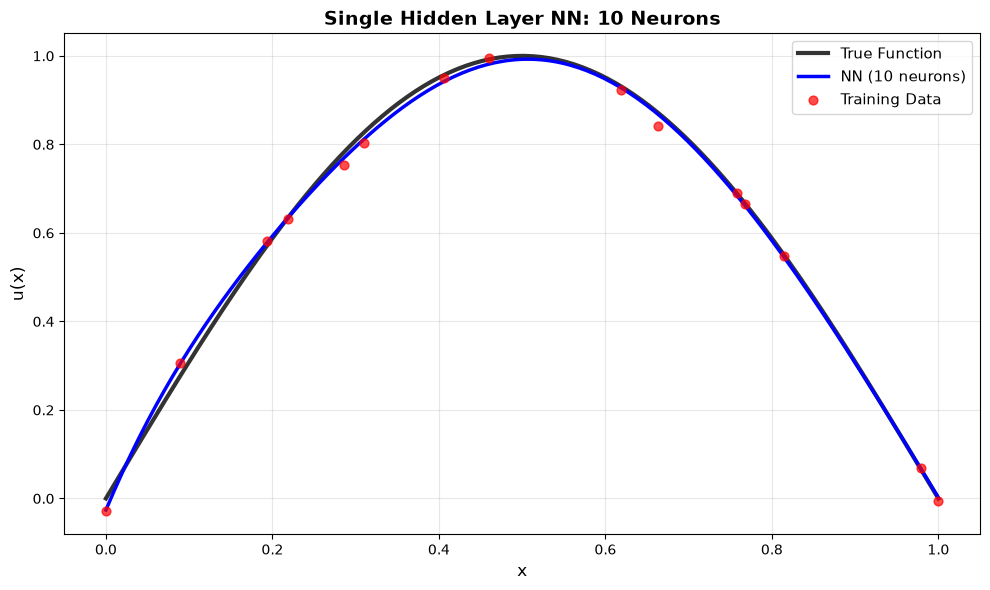

Training MSE: 0.000098
Test MSE: 0.000134


In [9]:
hidden_size = 10

model = SingleLayerNN(hidden_size=hidden_size)

# Train the model
losses = train_network(model, x_train_tensor, u_train_tensor, epochs=8000, lr=0.01)

# Handle different types of loss values
if isinstance(losses[-1], (list, np.ndarray)):
    # If it's a list or array, get the first element
    final_loss = float(losses[-1][0]) if len(losses[-1]) > 0 else float(losses[-1])
elif hasattr(losses[-1], 'item'):
    # If it's a tensor with .item() method
    final_loss = losses[-1].item()
else:
    # If it's already a scalar
    final_loss = float(losses[-1])

print(f"Final loss for {hidden_size} neurons: {final_loss:.6f}")

# Get predictions from the trained model
x_plot = x_test  # Use our test grid
x_test_tensor_plot = torch.tensor(x_plot.reshape(-1, 1), dtype=torch.float32)
u_analytical_plot = y_exact  # True function values

with torch.no_grad():
    u_pred = model(x_test_tensor_plot).numpy().flatten()

# Plotting
# Plot true function
plt.plot(x_plot, u_analytical_plot, 'k-', linewidth=3, label='True Function', alpha=0.8)

# Plot NN prediction
plt.plot(x_plot, u_pred, 'b-', linewidth=2.5, 
        label=f'NN ({hidden_size} neurons)')

# Plot training data points
plt.scatter(x_train, y_train, color='red', s=40, alpha=0.7, 
            label='Training Data', zorder=5)

plt.xlabel('x', fontsize=12)
plt.ylabel('u(x)', fontsize=12)
plt.title(f'Single Hidden Layer NN: {hidden_size} Neurons', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate errors
train_pred = model(x_train_tensor).detach().numpy().flatten()
train_error = np.mean((train_pred - y_train)**2)
test_error = np.mean((u_pred - u_analytical_plot)**2)

print(f"Training MSE: {train_error:.6f}")
print(f"Test MSE: {test_error:.6f}")